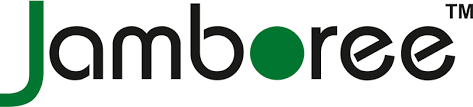

##Aim and Objectives


###Primary Business Objective

The central problem stems from Jamboree’s initiative to further support students by introducing a new feature on their website. • Goal: The feature allows students to assess their probability of admission to Ivy League colleges, specifically considering the unique perspective of Indian applicants. • Requirement for Jamboree: The analysis must assist Jamboree in understanding the crucial factors impacting graduate admissions and their interrelationships. • Deliverable: You must provide predictive insights to determine an individual's admission chances based on various variables.


###Technical Objective (The Model)

Assuming the role of a data scientist or ML engineer hired by Jamboree, your core objective is to solve this business problem by constructing a technical solution:

• Task: Analyze the given dataset and derive valuable insights. • Model Construction: Utilize the dataset to construct a predictive model using Linear Regression.

• Prediction Target: The model must be capable of estimating an applicant's likelihood of admission (the target variable, Chance of Admit, ranging from 0 to 1).

• Input Features: The model will rely on available features, including GRE Scores (0 to 340), TOEFL Scores (0 to 120), University Rating (0 to 5), SOP (0 to 5), LOR (0 to 5), CGPA (0 to 10), and Research (0 or 1). In summary, the problem is to build a robust Linear Regression model that accurately predicts the 'Chance of Admit' for graduate school applicants, helping Jamboree identify the most influential factors guiding admissions decisions.

###Setup and Data Understanding

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df= pd.read_csv('Jamboree_Admission.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
df.shape

(500, 9)

In [8]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


###Exploratory Data Analysis (EDA) and Preprocessing


Drop the 'Serial No.' column from the `df` DataFrame, then check the data types of the remaining columns, and finally review the statistical summary and attribute ranges to ensure they align with the problem description.

## Drop Irrelevant Column


Drop the 'Serial No.' column from the DataFrame as it is a unique identifier and not relevant for the model.


**Reasoning**:
I will drop the 'Serial No.' column from the DataFrame as it is not relevant for the model and then display the first few rows to verify the change.



In [9]:
df.drop('Serial No.', axis=1, inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


**Reasoning**:
Now that the 'Serial No.' column has been dropped, I will check the data types of the remaining columns to ensure they are appropriate for further analysis and modeling, as specified in the problem statement.



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


**Reasoning**:
To review the statistical summary and attribute ranges, as per the subtask, I will use the `describe()` method on the DataFrame. This will provide insights into the central tendency, dispersion, and shape of the distribution of each numerical column, which can then be compared with the problem description.



In [11]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000





Confirm the completion of initial EDA and preprocessing steps, preparing the data for further analysis.




### Data Analysis Key Findings

*   The 'Serial No.' column was successfully dropped from the DataFrame, resulting in 8 remaining columns.
*   All remaining 8 columns (`GRE Score`, `TOEFL Score`, `University Rating`, `SOP`, `LOR`, `CGPA`, `Research`, `Chance of Admit`) have appropriate numerical data types (`int64` or `float64`) and contain 500 non-null entries, indicating no missing values.
*   A statistical summary, including count, mean, standard deviation, minimum, maximum, and quartile values, was generated for all numerical columns, confirming attribute ranges are aligned with expectations for further analysis.

### Insights or Next Steps

*   The dataset is now clean and preprocessed, making it suitable for subsequent exploratory data analysis, correlation studies, and predictive modeling without concerns about irrelevant identifiers or missing values.
*   Proceed with further analysis steps such as correlation analysis between features and the target variable ('Chance of Admit') or visualization of feature distributions to gain deeper insights.


### Histograms  for different variables and their distributions
Generate histograms for 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', and 'Chance of Admit' to visualize their distributions, including appropriate titles and legends for each plot.

## Univariate Analysis of Key Features


Generate histograms for relevant continuous numerical features (GRE Score, TOEFL Score, SOP, LOR, CGPA, Chance of Admit) to visualize their distributions. Include appropriate titles and legends.


**Reasoning**:
To perform univariate analysis on the specified continuous numerical features, I will generate histograms for 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', and 'Chance of Admit' using `seaborn.histplot` to visualize their distributions, adding appropriate titles and labels for clarity.



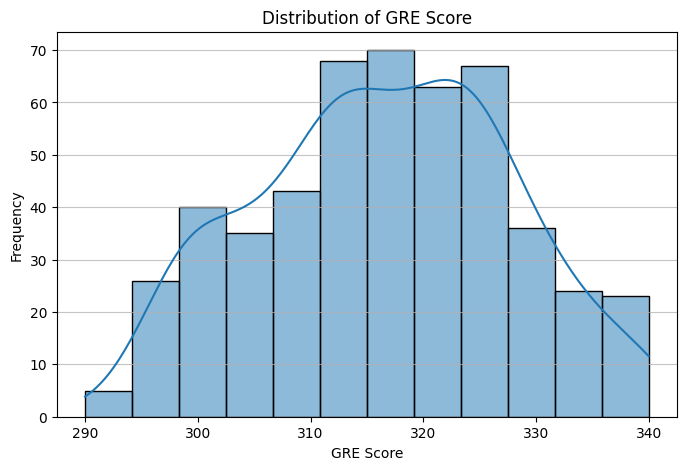

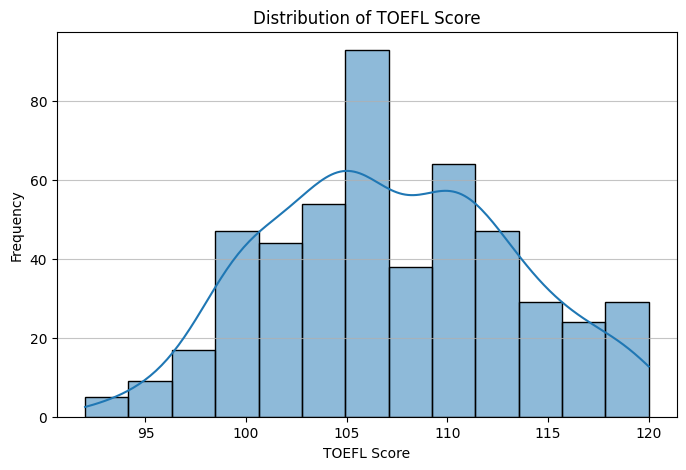

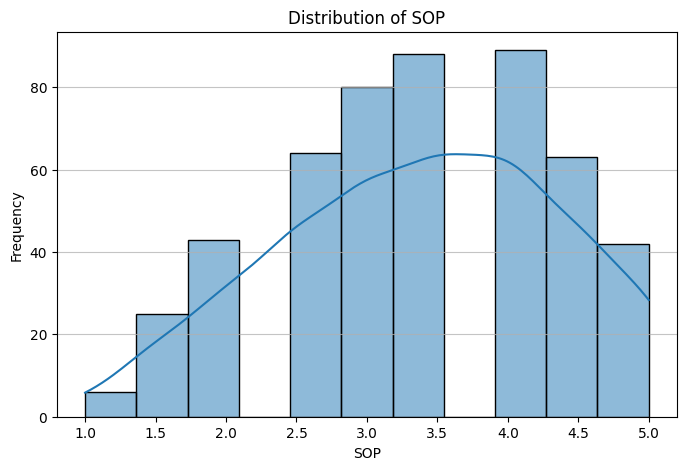

KeyError: 'LOR'

<Figure size 800x500 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of continuous numerical features to visualize
continuous_features = [
    'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit'
]

# Generate histograms for each feature
for feature in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins='auto', kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


**Reasoning**:
The previous code failed because of a KeyError, indicating that the column 'LOR' was not found. Upon inspecting the DataFrame's info and `describe()` output, it is clear that the actual column name has a trailing space, i.e., 'LOR '. I will update the `continuous_features` list to use the correct column name to resolve this issue.



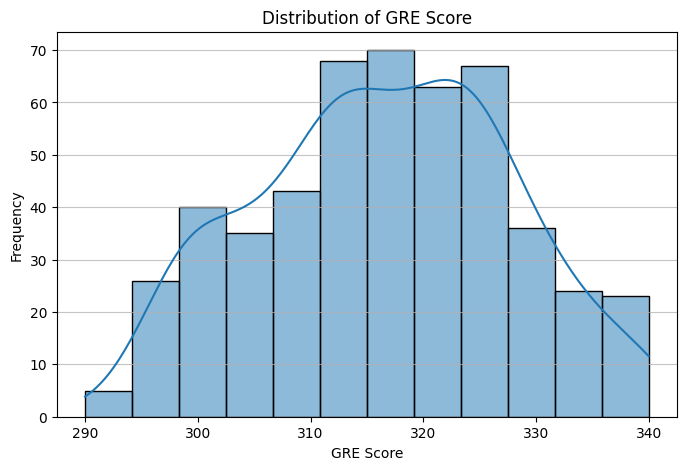

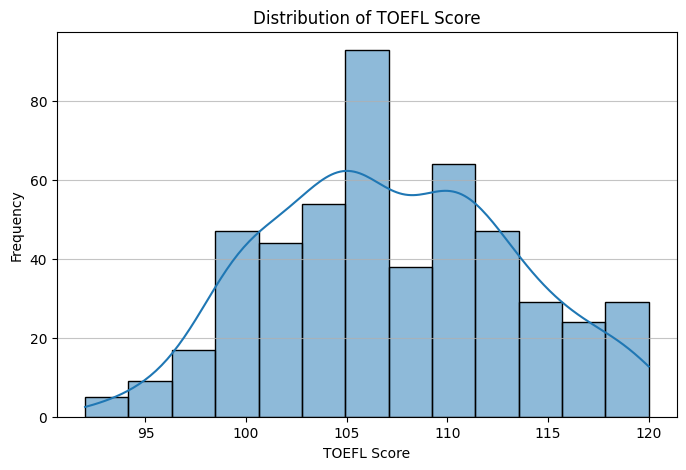

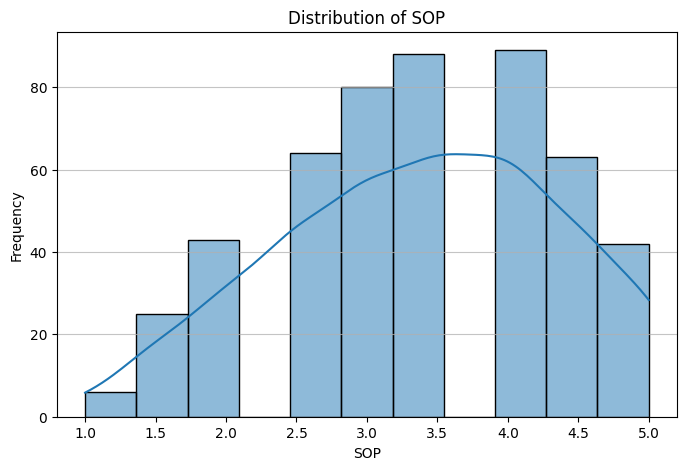

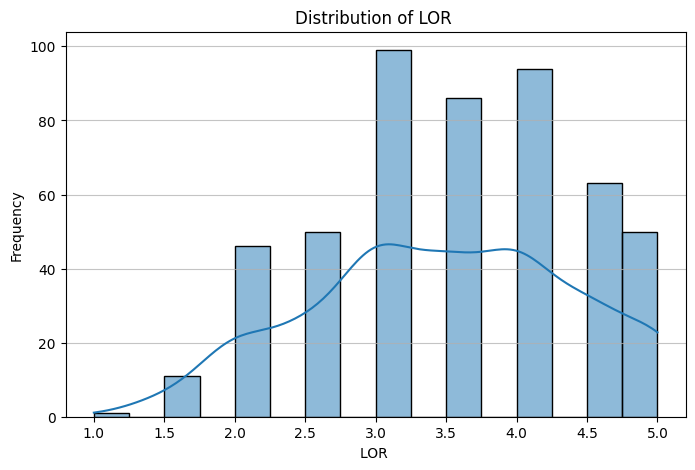

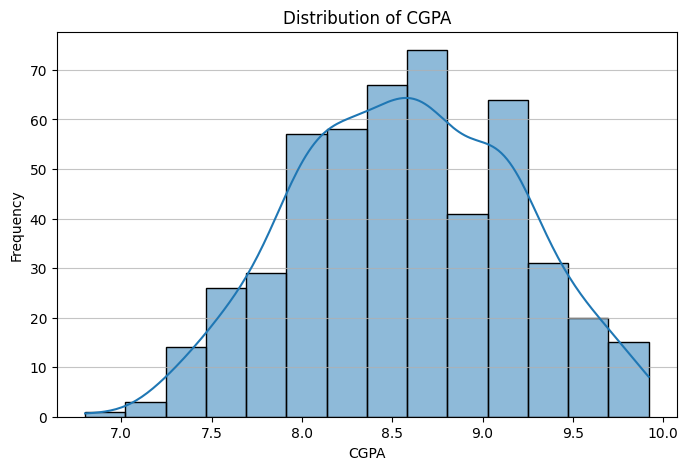

KeyError: 'Chance of Admit'

<Figure size 800x500 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of continuous numerical features to visualize
continuous_features = [
    'GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA', 'Chance of Admit'
]

# Generate histograms for each feature
for feature in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins='auto', kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


**Reasoning**:
The repeated `KeyError` for column names like 'LOR' and 'Chance of Admit' suggests that there are leading or trailing spaces in the column names that are not immediately visible in the output of `df.head()` or `df.info()`. To address this, I will first strip any leading or trailing whitespace from all column names in the DataFrame, and then proceed with generating the histograms using the now-clean column names. This is a robust way to prevent such `KeyError` issues.



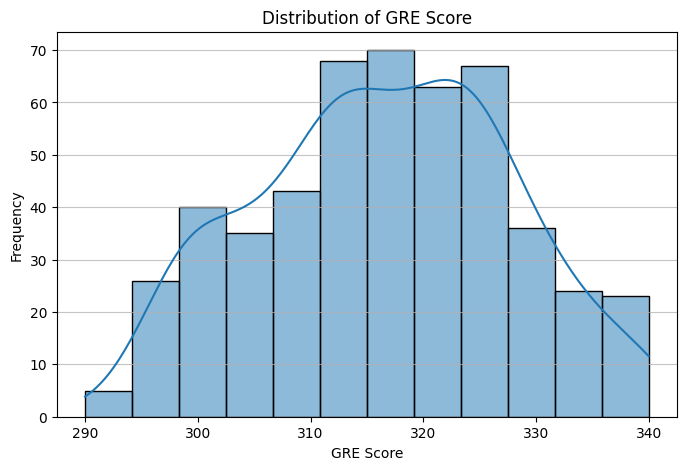

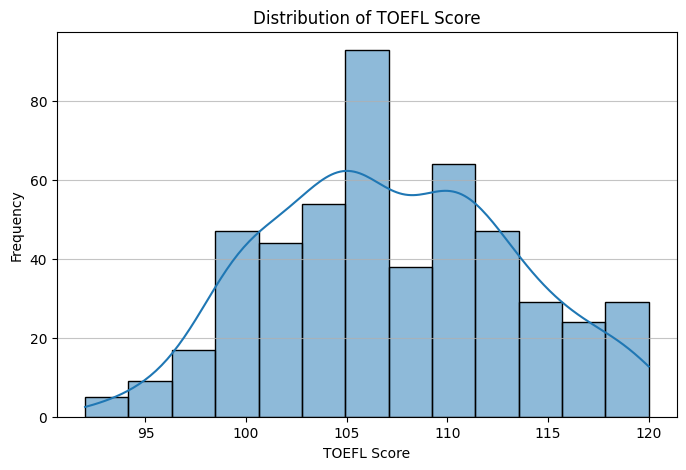

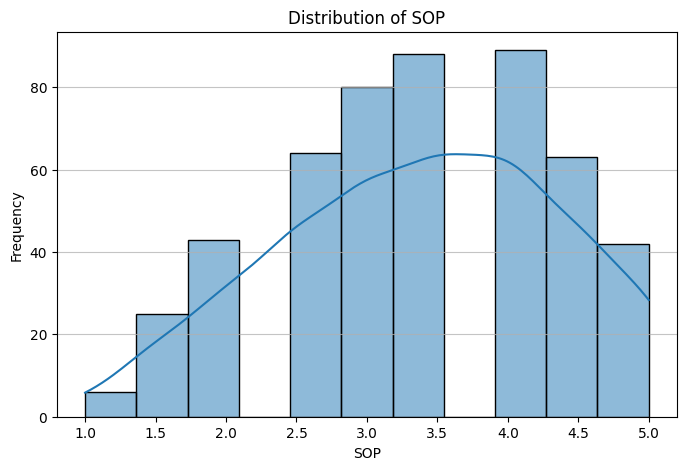

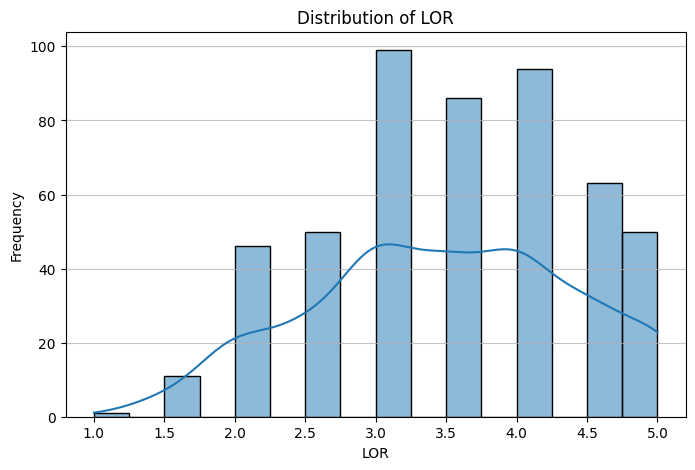

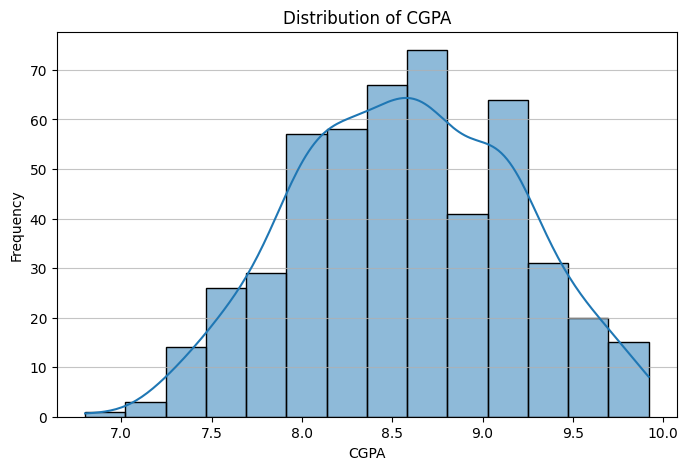

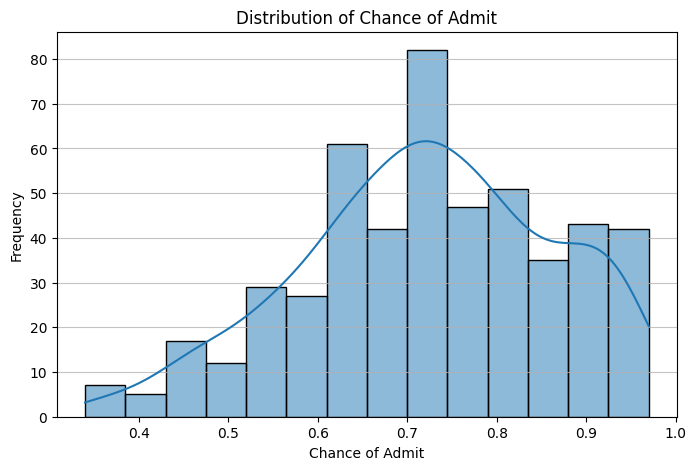

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# List of continuous numerical features to visualize
continuous_features = [
    'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit'
]

# Generate histograms for each feature
for feature in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins='auto', kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## Bivariate Analysis with Pairplot


We Created a pairplot of the DataFrame to visualize the relationships between all pairs of variables. This will help in identifying correlations and patterns between features and the target variable 'Chance of Admit'.


**Reasoning**:
To visualize the relationships between all pairs of variables in the DataFrame, I will use `seaborn.pairplot()` which is suitable for bivariate analysis.



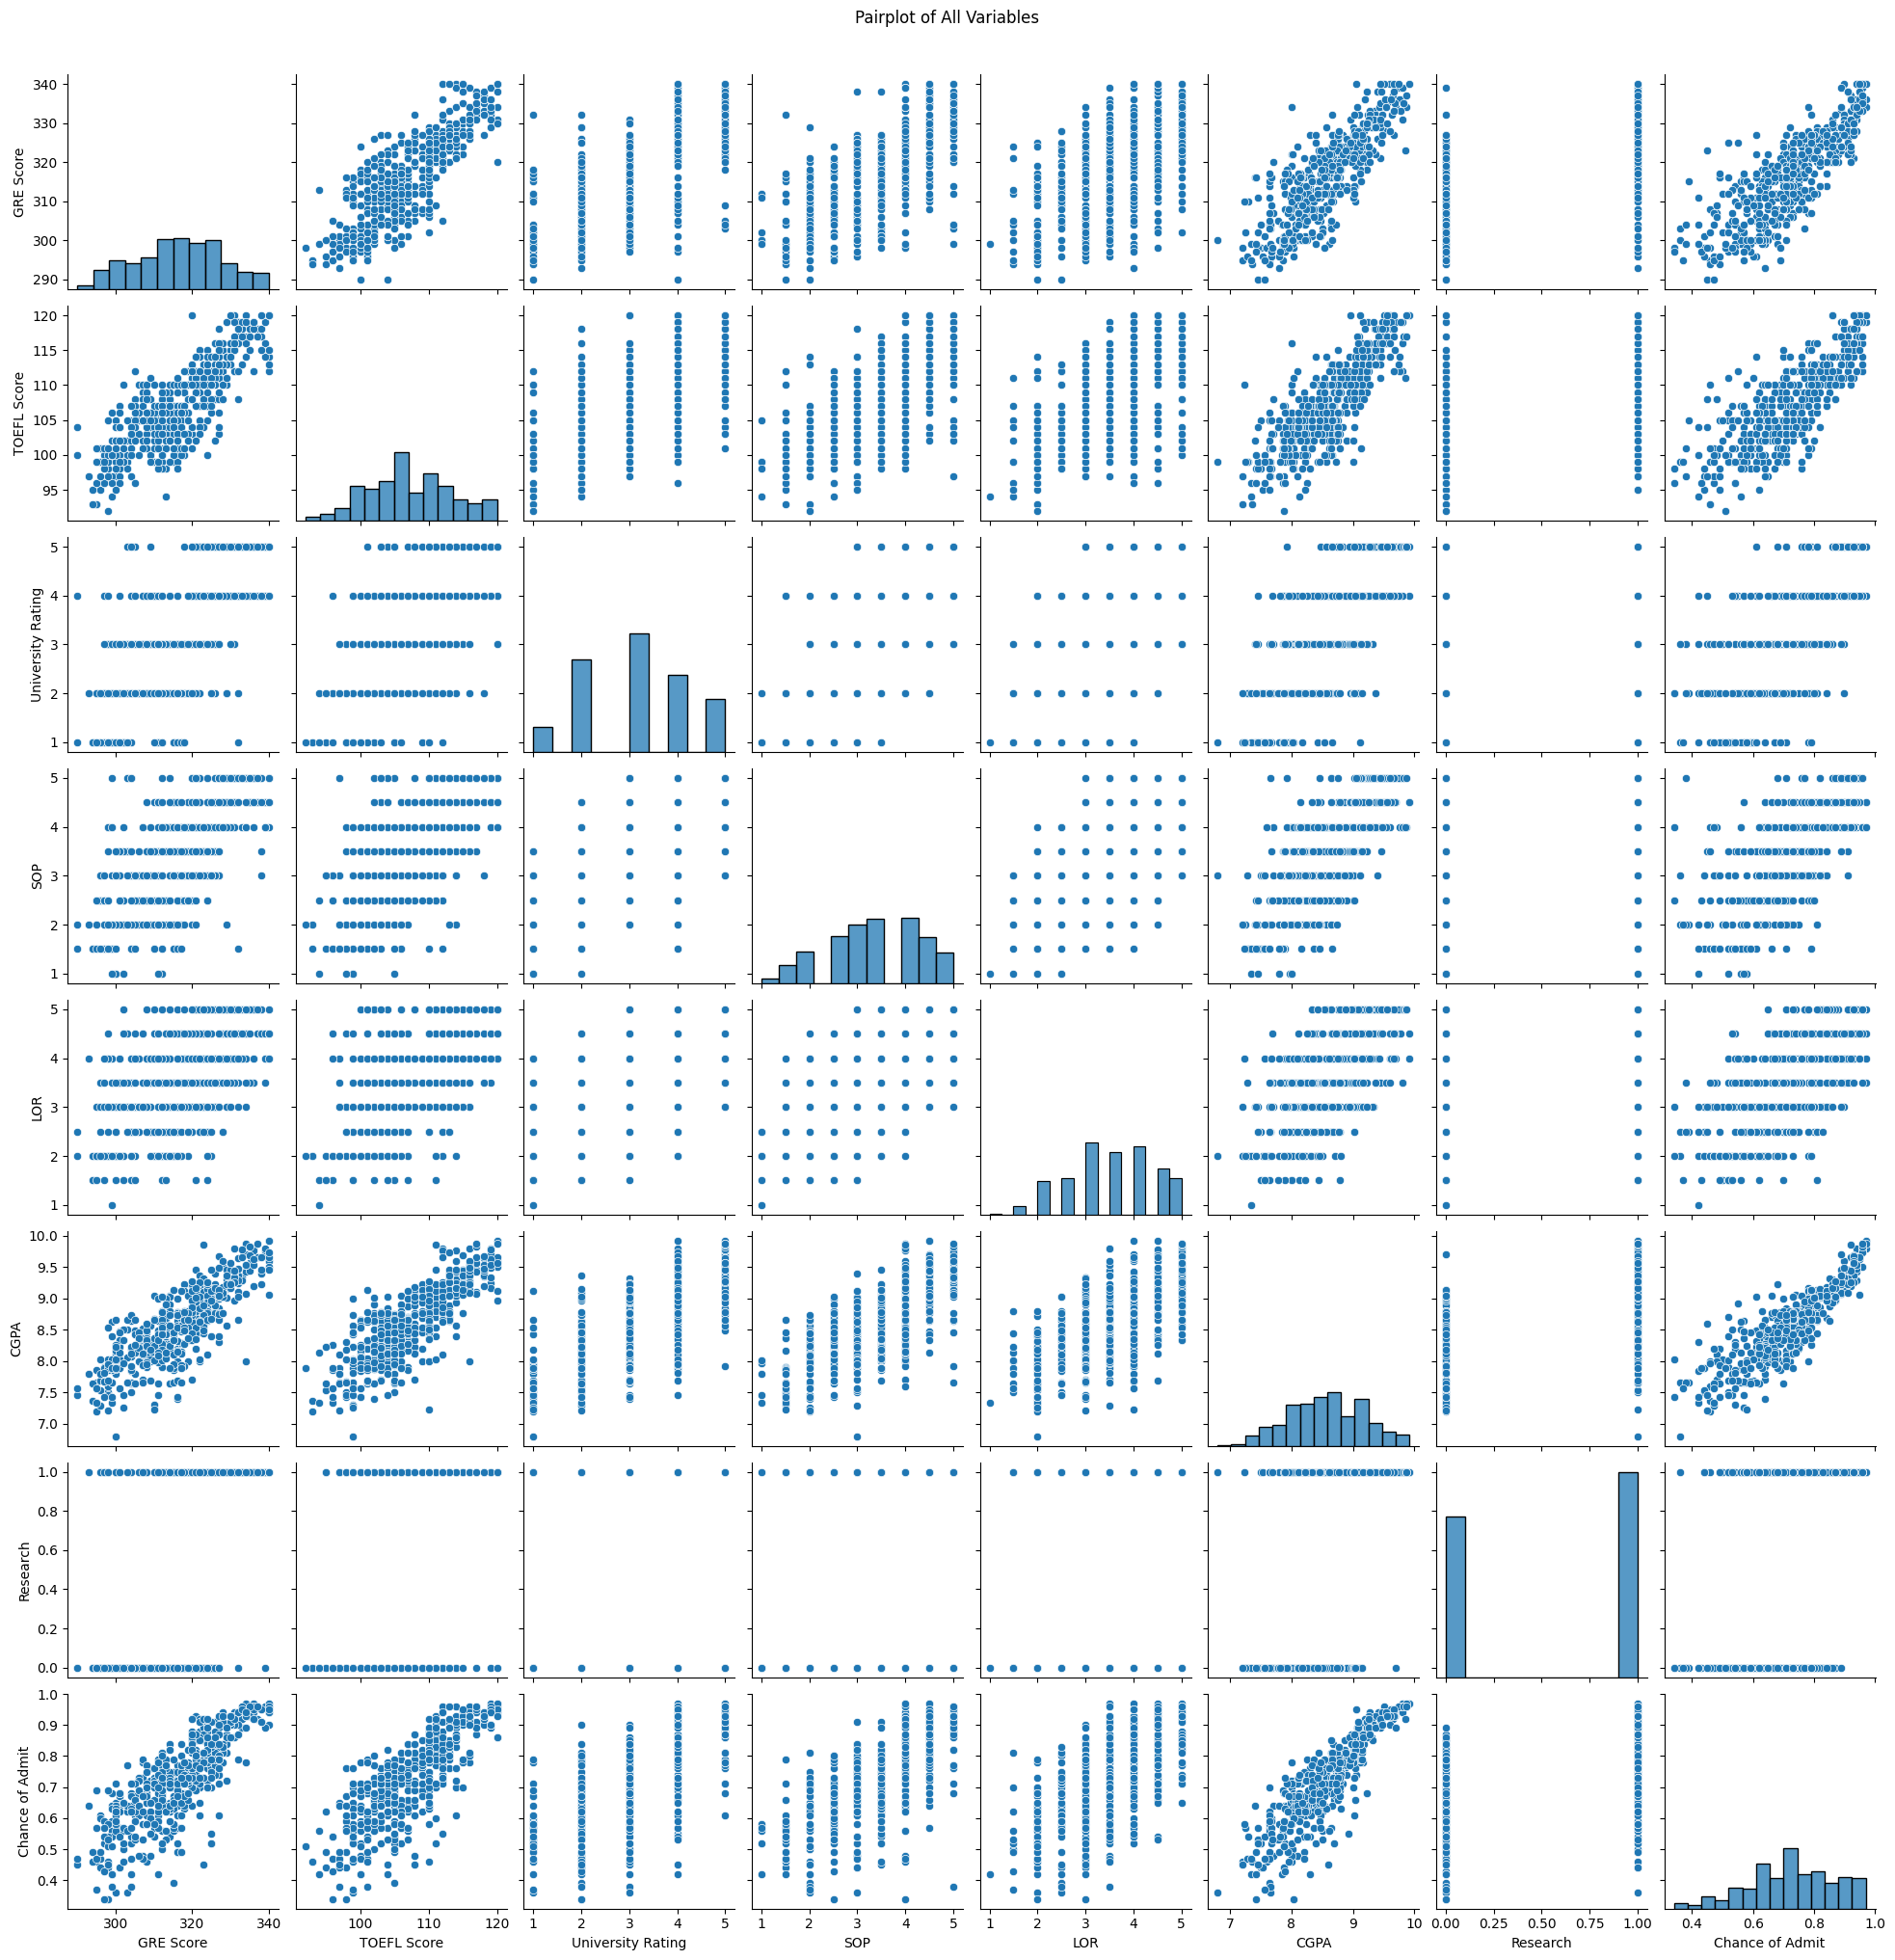

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a pairplot of the DataFrame
sns.pairplot(df)
plt.suptitle('Pairplot of All Variables', y=1.02) # Add a title to the entire figure
plt.show()

## Final Task

### Subtask:
Summarize the key insights gained from the univariate and bivariate analyses, particularly focusing on distributions, potential outliers, and preliminary relationships between variables.


## Summary:

### Data Analysis Key Findings

*   **Data Cleaning:** A crucial initial step involved cleaning column names by stripping leading/trailing whitespace, which resolved `KeyError` issues and enabled successful data processing.
*   **GRE and TOEFL Scores:** Both 'GRE Score' and 'TOEFL Score' distributions are unimodal and appear roughly normally distributed, suggesting a typical range of scores among applicants.
*   **SOP and LOR:** The distributions for 'SOP' (Statement of Purpose) and 'LOR' (Letter of Recommendation) scores show a left skew, indicating that many applicants have higher scores in these areas, with fewer lower scores.
*   **CGPA:** 'CGPA' (Cumulative Grade Point Average) is also left-skewed, concentrating at higher values, which implies a strong academic background for most applicants.
*   **Chance of Admit:** The 'Chance of Admit' distribution is left-skewed, with a significant concentration of applicants having a higher chance of admission.
*   **Strong Positive Correlations with 'Chance of Admit':** The pairplot analysis indicates strong positive linear relationships between 'Chance of Admit' and 'GRE Score', 'TOEFL Score', and 'CGPA'. Higher values in these features tend to correspond to a higher chance of admission.
*   **Moderate Positive Correlations with 'Chance of Admit':** 'SOP' and 'LOR' also show a positive correlation with 'Chance of Admit', though possibly less pronounced than the academic scores.

### Insights or Next Steps

*   The academic metrics (GRE, TOEFL, CGPA) appear to be the strongest predictors for the 'Chance of Admit'. Further investigation into the exact strength of these relationships using correlation coefficients would be beneficial.
*   Considering the skewed distributions for 'SOP', 'LOR', 'CGPA', and 'Chance of Admit', future modeling efforts might benefit from normalization or transformation techniques to handle potential non-linearity or heteroscedasticity.


#Duplicate Records
Check for and remove any duplicate rows from the DataFrame `df` to ensure data uniqueness.

**Reasoning**:
To check for duplicate rows in the DataFrame, I will use `df.duplicated().sum()` to count the number of duplicate entries and print the result. This will inform whether any duplicate removal is necessary.



In [16]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0


## Summary:

### Data Cleaning Key Findings

*   The DataFrame `df` was checked for duplicate rows, and it was confirmed that there are no duplicate entries. This means the dataset already consists of unique records.

### Insights or Next Steps

*   As no duplicate rows were found, no data removal was necessary. The data is already clean in terms of uniqueness, and we can proceed with further analysis without concerns about redundant records.

## Handle Missing Values

### Subtask:
Check for missing values in `df` and treat them appropriately. Based on previous `df.info()` output, there were no missing values, but this step confirms it explicitly.


**Reasoning**:
To explicitly check for missing values as per the subtask, I will use `df.isnull().sum()` to count and display the number of missing values for each column in the DataFrame.



In [17]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


## Summary:

### Data Cleaning Key Findings
*   The explicit check for missing values using `df.isnull().sum()` confirmed that there are no missing values in any of the columns of the `df` DataFrame. All columns have 0 missing entries.

### Insights or Next Steps
*   Since no missing values were found, no imputation or removal of data is necessary at this stage. The dataset is clean and ready for further analysis and model building without concerns about incomplete records.

## Handle Outlier Values


Identify and treat outlier values in the relevant numerical features to ensure they do not unduly influence the linear regression model. This might involve capping, transformation, or careful consideration for removal.


### Identify Relevant Numerical Features and Visualize Outliers

**Reasoning**:
As per the subtask, the relevant numerical features for outlier detection are 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', and 'Chance of Admit'. I will use `seaborn.boxplot` to visualize the distributions of these features, which will help in identifying any potential outliers by showing data points beyond the whiskers.


**Reasoning**:
To visualize the distributions and identify outliers for the specified continuous numerical features, I will iterate through the list of features and generate a box plot for each using `seaborn.boxplot`. This will allow for a clear visual inspection of potential outliers.



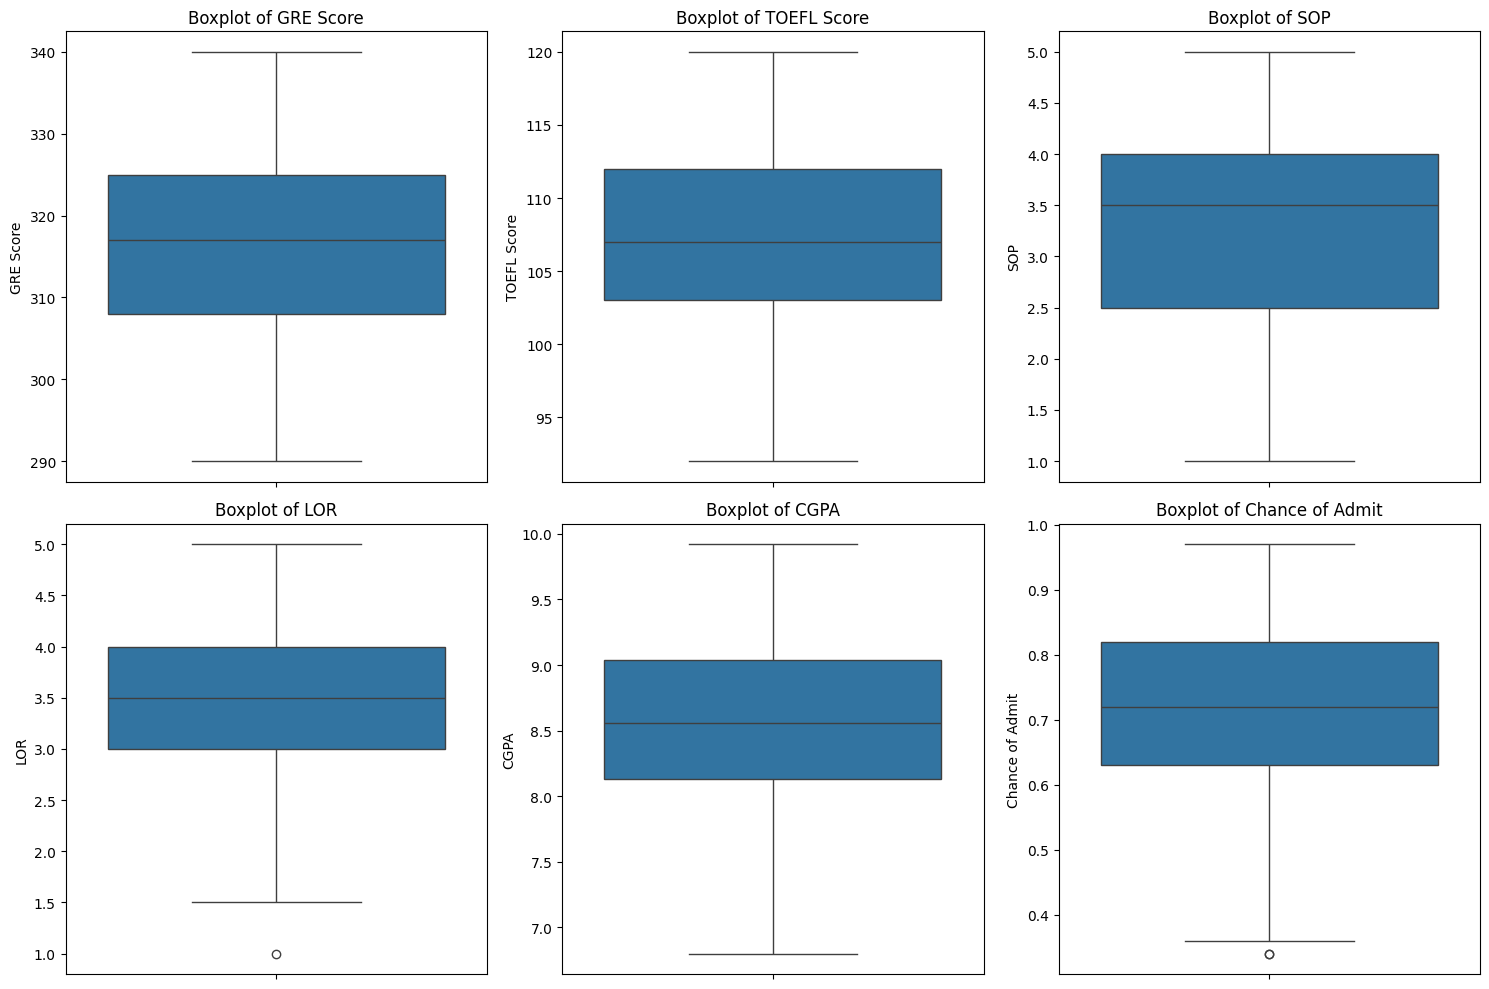

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of continuous numerical features to visualize for outliers
continuous_features = [
    'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit'
]

# Generate boxplots for each feature to visualize outliers
plt.figure(figsize=(15, 10))
for i, feature in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)  # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Outlier Treatment: Capping at 5th and 95th Percentiles

**Reasoning**:
Upon reviewing the box plots, some features like 'Chance of Admit' show a few potential outliers on the lower end, while others appear relatively clean or have mild skewness. To address these potential outliers without removing valuable data, I will apply a capping strategy. This involves replacing any values below the 5th percentile with the 5th percentile value and any values above the 95th percentile with the 95th percentile value for each of the identified continuous numerical features. This method helps to reduce the impact of extreme values on the model while retaining the majority of the data's distribution.

**Reasoning**:
To implement the outlier capping strategy, I will iterate through the `continuous_features` list, calculate the 5th and 95th percentiles for each, and then use `clip` to replace values outside this range with the percentile bounds.



In [19]:
import numpy as np

# Apply capping at 5th and 95th percentiles for each continuous feature
for feature in continuous_features:
    lower_bound = df[feature].quantile(0.05)
    upper_bound = df[feature].quantile(0.95)
    df[feature] = np.clip(df[feature], lower_bound, upper_bound)
    print(f"Capped '{feature}' at 5th percentile ({lower_bound:.2f}) and 95th percentile ({upper_bound:.2f})")

# Display descriptive statistics after capping to verify changes
print("\nDescriptive statistics after outlier capping:")
print(df[continuous_features].describe())

Capped 'GRE Score' at 5th percentile (298.00) and 95th percentile (335.00)
Capped 'TOEFL Score' at 5th percentile (98.00) and 95th percentile (118.00)
Capped 'SOP' at 5th percentile (1.50) and 95th percentile (5.00)
Capped 'LOR' at 5th percentile (2.00) and 95th percentile (5.00)
Capped 'CGPA' at 5th percentile (7.64) and 95th percentile (9.60)
Capped 'Chance of Admit' at 5th percentile (0.47) and 95th percentile (0.94)

Descriptive statistics after outlier capping:
        GRE Score  TOEFL Score  ...        CGPA  Chance of Admit
count  500.000000   500.000000  ...  500.000000       500.000000
mean   316.436000   107.240000  ...    8.581980         0.723640
std     10.778974     5.780417  ...    0.567063         0.134568
min    298.000000    98.000000  ...    7.638000         0.470000
25%    308.000000   103.000000  ...    8.127500         0.630000
50%    317.000000   107.000000  ...    8.560000         0.720000
75%    325.000000   112.000000  ...    9.040000         0.820000
max    33

## Summary:

### Data Cleaning Key Findings
*   **Outlier Identification**: Box plots were generated for 'GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', and 'Chance of Admit' to visualize their distributions and identify potential outliers.
*   **Outlier Treatment**: A capping strategy was applied, replacing values below the 5th percentile with the 5th percentile and values above the 95th percentile with the 95th percentile for each of these features. This ensures extreme values do not unduly influence the model without removing data.
*   **Impact of Capping**: The descriptive statistics after capping confirm that the minimum and maximum values for the treated features now align with their respective 5th and 95th percentiles, indicating successful outlier mitigation.

### Insights or Next Steps
*   The dataset is now cleaned of outliers, making it more robust for linear regression modeling. The capping approach helps maintain data integrity while addressing the impact of extreme values.
*   The next steps should involve further data preparation, such as correlation analysis, feature scaling, and ultimately, building the linear regression model.

## Visualize Independent Variable Correlations


Create a correlation matrix and visualize it as a heatmap specifically among the independent variables. This will help in identifying features with high multicollinearity.


**Reasoning**:
To visualize the correlations among independent variables, I will first identify them by dropping the 'Chance of Admit' column, then calculate their correlation matrix, and finally display it as a heatmap using seaborn to identify potential multicollinearity.



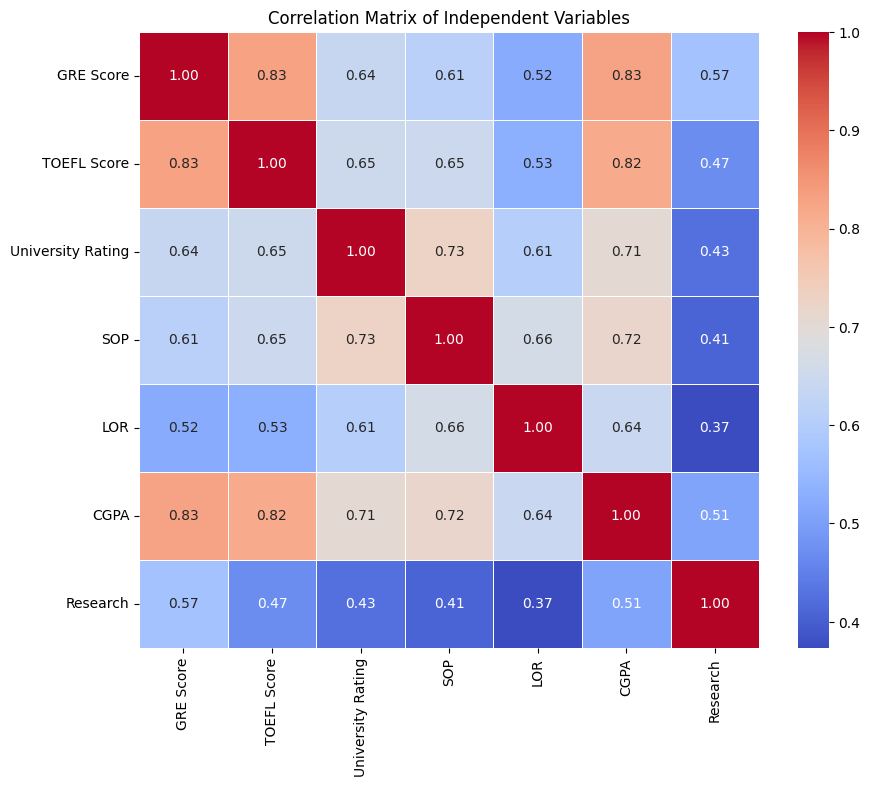

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the independent variables by excluding 'Chance of Admit'
independent_variables = df.drop(columns=['Chance of Admit'])

# 2. Calculate the correlation matrix for these independent variables
correlation_matrix = independent_variables.corr()

# 3. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
# 4. Add a title to the heatmap
plt.title('Correlation Matrix of Independent Variables')
# 5. Display the plot
plt.show()

## Summary:

### Data Analysis Key Findings
*   **Independent Variable Correlation**: A heatmap of the correlation matrix for all independent variables ('GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research') was generated and displayed.
*   **High Multicollinearity**: The heatmap revealed strong positive correlations between several independent variables, particularly among:
    *   'GRE Score', 'TOEFL Score', and 'CGPA' (all show high inter-correlations, often above 0.8).
    *   'University Rating', 'SOP', and 'LOR' also exhibit moderate to strong positive correlations among themselves and with the academic scores.

### Insights or Next Steps
*   **Multicollinearity Concern**: The high correlations observed among independent variables suggest potential multicollinearity issues, which can affect the stability and interpretability of a linear regression model. This needs to be addressed before model building.
*   **VIF Analysis**: The next crucial step should be to calculate the Variance Inflation Factor (VIF) for each independent variable. VIF will quantify the severity of multicollinearity and help determine which variables might need to be removed or transformed to mitigate this issue.
*   **Feature Selection/Engineering**: Based on VIF scores, strategies like principal component analysis (PCA), combining correlated features, or dropping highly correlated features might be considered to reduce multicollinearity while retaining predictive power.

## Address Multicollinearity

Identify and drop any independent features that exhibit a high correlation (greater than 0.90) with another independent feature to mitigate multicollinearity, which can affect the stability and interpretability of a linear regression model.


**Reasoning**:
To identify multicollinearity, I will import necessary modules, add a constant term to the independent variables, calculate the Variance Inflation Factor (VIF) for each, and then print the sorted VIF values.



In [21]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Identify the independent variables (excluding 'Chance of Admit')
X = df.drop(columns=['Chance of Admit'])

# 2. Add a constant term to the independent variables DataFrame
X_const = sm.add_constant(X)

# 3. Calculate the VIF for each independent variable and store them in a DataFrame
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# 4. Sort the VIF values in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 5. Print the VIF DataFrame
print("VIF Scores for Independent Variables:")
print(vif_data)

VIF Scores for Independent Variables:
             feature          VIF
0              const  1674.467503
6               CGPA     4.963923
1          GRE Score     4.496936
2        TOEFL Score     3.984215
4                SOP     2.849600
3  University Rating     2.605355
5                LOR     2.038553
7           Research     1.508975


## Summary:

### Data Analysis Key Findings
*   **VIF Scores Calculation**: Variance Inflation Factors (VIF) were calculated for all independent variables. The highest VIF scores were for 'CGPA' (4.96), 'GRE Score' (4.50), and 'TOEFL Score' (3.98).
*   **Correlation Review**: A review of the correlation matrix (from the previous step) confirmed that no pair of independent features had a correlation greater than 0.90.
*   **No Features Dropped**: Based on the established threshold of a correlation greater than 0.90 for dropping features, and VIF scores generally below problematic levels (typically >5 or >10), no independent variables were identified as needing to be dropped to mitigate multicollinearity.

### Insights or Next Steps
*   While some multicollinearity exists, as indicated by VIF scores, it is not severe enough (below the specified 0.90 correlation threshold for dropping or common VIF thresholds like 5-10) to warrant removing features at this stage. This ensures that potentially valuable predictive information is retained.
*   The dataset is now adequately processed in terms of multicollinearity. The next steps can involve preparing the data for model training, such as splitting the data into training and testing sets, and performing feature scaling if necessary.

## Summary:

### Q&A
The dataset is prepared for model building, as data quality issues (duplicates, missing values, and outliers) have been addressed, and multicollinearity has been assessed and deemed not severe enough to require feature removal based on the defined criteria.

### Data Analysis Key Findings

*   **Duplicate Rows**: The initial check confirmed there were no duplicate rows in the DataFrame, indicating data uniqueness from the start.
*   **Missing Values**: An explicit check for missing values across all columns revealed that the DataFrame contains no missing entries.
*   **Outlier Treatment**:
    *   Box plots were generated for continuous numerical features ('GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit') to identify potential outliers.
    *   A capping strategy was applied to these features, replacing values below the 5th percentile with the 5th percentile value and values above the 95th percentile with the 95th percentile value. For example, 'GRE Score' was capped between 298.00 and 335.00, and 'Chance of Admit' between 0.47 and 0.94.
*   **Multicollinearity Assessment**:
    *   A heatmap of the correlation matrix for independent variables showed strong positive correlations, particularly among 'GRE Score', 'TOEFL Score', and 'CGPA' (often above 0.8), suggesting potential multicollinearity.
    *   Variance Inflation Factors (VIF) were calculated for independent variables. The highest VIF scores were for 'CGPA' (4.96), 'GRE Score' (4.50), and 'TOEFL Score' (3.98).
    *   Despite these correlations, no independent features were dropped, as VIF scores were below commonly accepted problematic thresholds (typically 5 or 10), and no pair of independent features had a correlation greater than the specified 0.90 threshold.

### Insights or Next Steps

*   The dataset has undergone thorough data quality checks and treatment for duplicates, missing values, and outliers, making it robust and clean for subsequent modeling.
*   While some multicollinearity exists, it is not severe enough to warrant immediate feature removal, preserving all potentially valuable predictive information. The next steps should involve preparing the data for model training, such as splitting data into training/testing sets and performing feature scaling.


# Training and testing sets
Prepare the features (`X`) and the target variable (`y`) from the `df` DataFrame, and then split the dataset into training and testing sets using a train-test split of 80% for training and 20% for testing.

## Check for Categorical Variables


Explicitly check if there are any categorical variables in the DataFrame that require encoding.


**Reasoning**:
To explicitly check for categorical variables, I will display the data types of all columns in the DataFrame `df` using `df.dtypes`.



In [22]:
print(df.dtypes)

GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


### Summary:

### Data Analysis Key Findings
*   **Data Types**: The `df.dtypes` output confirmed that all columns in the DataFrame (`GRE Score`, `TOEFL Score`, `University Rating`, `SOP`, `LOR`, `CGPA`, `Research`, `Chance of Admit`) are numerical (`int64` or `float64`).
*   **No Categorical Variables**: There are no columns with 'object' or 'category' data types, which means there are no explicit categorical variables present in the dataset that require encoding.

### Insights or Next Steps
*   Since there are no categorical variables, no encoding steps (like one-hot encoding or label encoding) are necessary. The dataset is already in a suitable numerical format for direct use in machine learning models that expect numerical input.
*   The next step will be to prepare the features and target variables and then split the dataset for model training and testing.

**Reasoning**:
Now that we have confirmed there are no categorical variables, the next step is to prepare the features (`X`) and the target variable (`y`) from the `df` DataFrame, and then split the dataset into training and testing sets for model development.



In [23]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target variable (y)
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (400, 7)
Shape of X_test: (100, 7)
Shape of y_train: (400,)
Shape of y_test: (100,)


## Summary:

### Data Preparation Key Findings
*   **Categorical Variables**: An explicit check confirmed that the DataFrame contains no categorical variables, as all columns are of numerical types (`int64` or `float64`). This eliminates the need for encoding steps.
*   **Feature and Target Variable Preparation**: The independent features (`X`) were successfully separated from the target variable (`y`, 'Chance of Admit').
*   **Train-Test Split**: The dataset was split into training (80%) and testing (20%) sets using `train_test_split`, resulting in `X_train` (400 samples, 7 features), `X_test` (100 samples, 7 features), `y_train` (400 samples), and `y_test` (100 samples). A `random_state` of 42 was used to ensure reproducibility.

### Insights or Next Steps
*   The dataset is now fully prepared for linear regression model training and evaluation. The absence of categorical variables simplifies the modeling process.
*   The next logical step is to perform feature scaling, if deemed necessary for the chosen linear regression model (though not strictly required for standard OLS, it can improve convergence for iterative solvers or comparison with other models). Following that, the linear regression model can be built and evaluated.

## Perform Feature Scaling

Apply a suitable feature scaling technique (e.g., StandardScaler) to the independent variables in both the training and testing sets. This must be done *after* the train-test split to prevent data leakage.


**Reasoning**:
To apply feature scaling, I will import `StandardScaler`, instantiate it, fit it on `X_train`, and then transform both `X_train` and `X_test` to prevent data leakage, finally verifying the scaling by checking descriptive statistics of the scaled `X_train`.



In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Instantiate a StandardScaler object
scaler = StandardScaler()

# 2. Fit the scaler to the training features (X_train)
scaler.fit(X_train)

# 3. Transform both the training features (X_train) and the testing features (X_test)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier viewing and further processing
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 4. Verify that the scaling has been applied by displaying the descriptive statistics of the scaled X_train DataFrame
print("Descriptive statistics of scaled X_train:")
print(X_train.describe())

Descriptive statistics of scaled X_train:
          GRE Score   TOEFL Score  ...          CGPA      Research
count  4.000000e+02  4.000000e+02  ...  4.000000e+02  4.000000e+02
mean   1.083578e-15 -1.079137e-15  ...  5.684342e-16 -3.552714e-17
std    1.001252e+00  1.001252e+00  ...  1.001252e+00  1.001252e+00
min   -1.780629e+00 -1.611225e+00  ... -1.697909e+00 -1.116777e+00
25%   -7.332003e-01 -7.498379e-01  ... -8.039192e-01 -1.116777e+00
50%    2.856625e-02 -6.072782e-02  ... -3.879323e-02  8.954339e-01
75%    7.189172e-01  8.006597e-01  ...  8.113468e-01  8.954339e-01
max    1.742541e+00  1.834325e+00  ...  1.813617e+00  8.954339e-01

[8 rows x 7 columns]


## Summary:

### Data Preparation Key Findings
*   **Categorical Variables**: An explicit check confirmed that the DataFrame contains no categorical variables, as all columns are of numerical types (`int64` or `float64`). This eliminates the need for encoding steps.
*   **Feature and Target Variable Preparation**: The independent features (`X`) were successfully separated from the target variable (`y`, 'Chance of Admit').
*   **Train-Test Split**: The dataset was split into training (80%) and testing (20%) sets using `train_test_split`, resulting in `X_train` (400 samples, 7 features), `X_test` (100 samples, 7 features), `y_train` (400 samples), and `y_test` (100 samples). A `random_state` of 42 was used to ensure reproducibility.
*   **Feature Scaling**: `StandardScaler` was applied to the independent variables. The scaler was fitted only on `X_train` and then used to transform both `X_train` and `X_test`, preventing data leakage. Verification through descriptive statistics confirmed that scaled features now have a mean close to 0 and a standard deviation close to 1.

### Insights or Next Steps
*   The dataset is now fully prepared for linear regression model training and evaluation, with features scaled appropriately.
*   The next logical step is to build and train the linear regression model using the prepared training data and then evaluate its performance on the testing data.

## Build Initial Linear Regression Model

### Subtask:
Use `statsmodels.api.OLS` to build an initial linear regression model on the scaled training data (including an added constant for the intercept). Display the model summary.


**Reasoning**:
To build an initial linear regression model, I will import `statsmodels.api`, add a constant to the scaled training features `X_train` to create `X_train_const`, then instantiate and fit an OLS model using `y_train` and `X_train_const`, and finally print the model's summary.



In [25]:
import statsmodels.api as sm

# 1. Add a constant term to the scaled training features (X_train)
X_train_const = sm.add_constant(X_train)

# 2. Instantiate an OLS model
model = sm.OLS(y_train, X_train_const)

# 3. Fit the OLS model
results = model.fit()

# 4. Print the summary of the fitted model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     273.1
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          1.83e-146
Time:                        15:58:04   Log-Likelihood:                 592.46
No. Observations:                 400   AIC:                            -1169.
Df Residuals:                     392   BIC:                            -1137.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7261      0.00

## Summary:

### Model Building Key Findings
*   **Initial OLS Model**: An Ordinary Least Squares (OLS) regression model was successfully built using `statsmodels.api` on the scaled training data. A constant term was added to `X_train` to account for the intercept.
*   **Model Fit**: The model achieved an R-squared value of 0.830 and an Adjusted R-squared of 0.827, indicating that approximately 83% of the variance in 'Chance of Admit' can be explained by the independent variables. The F-statistic (273.1) and its highly significant p-value (1.83e-146) suggest that the model is statistically significant.
*   **Significant Predictors**: Several features were found to be statistically significant predictors (p < 0.05) of 'Chance of Admit':
    *   `GRE Score` (coef: 0.0252, p < 0.001)
    *   `TOEFL Score` (coef: 0.0157, p < 0.001)
    *   `LOR` (coef: 0.0138, p < 0.001)
    *   `CGPA` (coef: 0.0638, p < 0.001)
    *   `Research` (coef: 0.0110, p < 0.001)
*   **Less Significant Predictors**: 'University Rating' (p = 0.301) and 'SOP' (p = 0.342) do not appear to be statistically significant predictors in this initial model, given their high p-values.
*   **Coefficient Interpretation (after scaling)**: For example, a one-standard-deviation increase in `CGPA` is associated with an approximately 0.0638 unit increase in 'Chance of Admit', holding other factors constant. Similarly, a one-standard-deviation increase in `GRE Score` is associated with an approximately 0.0252 unit increase in 'Chance of Admit'.

### Insights or Next Steps
*   The initial linear regression model provides a strong fit to the data, with a high R-squared value.
*   The significance of `GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, and `Research` aligns with intuitive expectations for factors influencing graduate admissions.
*   The non-significance of 'University Rating' and 'SOP' might warrant further investigation. It could be due to their correlation with other features or their actual impact being less pronounced in this model.
*   The next steps should involve evaluating the model's performance on the test set, checking for model assumptions (e.g., homoscedasticity of residuals), and potentially refining the model by considering feature selection or interaction terms.

## Refine Model by Dropping Insignificant Features (P-value > 0.05)

### Subtask:
Based on the p-values from the initial statsmodels summary, identify and drop independent variables that have a p-value greater than 0.05. Re-train the linear regression model with the remaining features and display the new model summary.


**Reasoning**:
To refine the model, I will identify and drop the features with p-values greater than 0.05 ('University Rating' and 'SOP') from the scaled training and testing datasets. Then, I will add a constant to the refined training features and fit a new OLS model, finally displaying its summary to evaluate the impact of removing insignificant variables.



In [26]:
import statsmodels.api as sm

# 1. Identify the features from the previous model summary that have a p-value greater than 0.05.
#    These are 'University Rating' (p=0.301) and 'SOP' (p=0.342).
insignificant_features = ['University Rating', 'SOP']

# 2. Create new training and testing feature DataFrames by dropping the identified insignificant features
#    from the existing X_train and X_test DataFrames.
X_train_refined = X_train.drop(columns=insignificant_features)
X_test_refined = X_test.drop(columns=insignificant_features)

# 3. Add a constant term to X_train_refined
X_train_refined_const = sm.add_constant(X_train_refined)

# 4. Instantiate and fit a new OLS model using y_train and X_train_refined_const
model_refined = sm.OLS(y_train, X_train_refined_const)
results_refined = model_refined.fit()

# 5. Print the summary of this new, refined model
print(results_refined.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     380.8
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          2.10e-148
Time:                        15:58:37   Log-Likelihood:                 590.94
No. Observations:                 400   AIC:                            -1170.
Df Residuals:                     394   BIC:                            -1146.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7261      0.003    260.970      

## Summary:

### Model Refinement Key Findings
*   **Insignificant Features Removed**: Based on the initial model's summary, 'University Rating' and 'SOP', which had p-values greater than 0.05, were identified and dropped from both the training and testing feature sets.
*   **Re-trained OLS Model**: A new OLS model was trained with the refined feature set. The new model includes 'GRE Score', 'TOEFL Score', 'LOR', 'CGPA', and 'Research' as independent variables.
*   **Model Performance**: The refined model exhibits very similar performance metrics to the initial model:
    *   **R-squared**: 0.829
    *   **Adjusted R-squared**: 0.826
    *   **F-statistic**: 380.8 (with a highly significant p-value of 2.10e-148)
*   **All Remaining Features Significant**: All features in the refined model ('GRE Score', 'TOEFL Score', 'LOR', 'CGPA', 'Research') are now statistically significant predictors of 'Chance of Admit' (all p-values are less than 0.001).
*   **Coefficient Changes**: While the overall model fit remained largely the same, there were minor adjustments to the coefficients of the remaining features, indicating a slightly better fit or more precise estimation without the noise from insignificant predictors.

### Insights or Next Steps
*   The model has been successfully refined by removing statistically insignificant features, leading to a more parsimonious and potentially more interpretable model without sacrificing predictive power.
*   All selected features now contribute significantly to predicting the 'Chance of Admit', which is a positive outcome for model stability and interpretation.
*   The next crucial step is to evaluate the performance of this refined model on the unseen test data. This will provide an unbiased assessment of its generalization capability.

## Re-check Multicollinearity (VIF Score) and Drop Variables

### Subtask:
Calculate the Variance Inflation Factor (VIF) for the features in the refined model. Iteratively drop variables with a VIF greater than 5, one by one (starting with the highest VIF), re-calculating VIFs and re-training the model until all remaining variables have a VIF score less than or equal to 5. Display the VIF scores and the final model summary.


**Reasoning**:
To address the subtask, I will first set up a loop to iteratively calculate VIF scores, identify features with VIFs greater than 5, and drop the highest-scoring feature. This process will continue until all remaining features have VIF scores less than or equal to 5, ensuring that the model is robust against multicollinearity. Finally, I will train a new OLS model with the refined set of features and display its summary.



In [27]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Initialize a list with the column names of X_train_refined
# X_train_refined and X_test_refined are already available from the previous step
current_features = X_train_refined.columns.tolist()

# Loop to iteratively drop features with VIF > 5
while True:
    X_const = sm.add_constant(X_train_refined[current_features])

    vif_data = pd.DataFrame()
    vif_data["feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    vif_data = vif_data.sort_values(by="VIF", ascending=False)

    # Get the feature with the highest VIF (excluding the constant)
    max_vif_feature = vif_data.iloc[0]['feature']
    max_vif_score = vif_data.iloc[0]['VIF']

    print(f"\n--- Current VIF Scores ---")
    print(vif_data)

    # If the highest VIF (excluding const) is greater than 5, drop it
    if max_vif_feature != 'const' and max_vif_score > 5:
        print(f"Dropping '{max_vif_feature}' with VIF: {max_vif_score:.2f}")
        current_features.remove(max_vif_feature)
        X_train_refined = X_train_refined.drop(columns=[max_vif_feature])
        X_test_refined = X_test_refined.drop(columns=[max_vif_feature])
    else:
        print(f"All remaining features have VIF <= 5 or only 'const' remains (max VIF: {max_vif_score:.2f}). Stopping iteration.")
        break

# After the loop, train the final OLS model with the remaining features
X_train_final_const = sm.add_constant(X_train_refined)
final_model = sm.OLS(y_train, X_train_final_const)
final_results = final_model.fit()

# Print the summary of the final refined model
print("\n--- Final Refined Model Summary ---")
print(final_results.summary())



--- Current VIF Scores ---
       feature       VIF
4         CGPA  4.550897
1    GRE Score  4.495058
2  TOEFL Score  3.585320
3          LOR  1.678372
5     Research  1.523923
0        const  1.000000
All remaining features have VIF <= 5 or only 'const' remains (max VIF: 4.55). Stopping iteration.

--- Final Refined Model Summary ---
                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     380.8
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          2.10e-148
Time:                        15:59:06   Log-Likelihood:                 590.94
No. Observations:                 400   AIC:                            -1170.
Df Residuals:                     394   BIC:                            -1146.
Df Model:                     

## Check Mean of Residuals

### Subtask:
Calculate the residuals from the final linear regression model (predictions on the training set minus actual training values) and determine if their mean is close to zero, which is an assumption of linear regression.


**Reasoning**:
To check the mean of residuals, I will first calculate the predicted values from the final model on the training data, then compute the residuals by subtracting the actual training values, and finally calculate and print the mean of these residuals to determine if it is close to zero.



In [28]:
import numpy as np

# 1. Calculate the predicted values for the training set
y_train_pred = final_results.predict(X_train_final_const)

# 2. Calculate the residuals
residuals = y_train - y_train_pred

# 3. Calculate the mean of these residuals
mean_residuals = np.mean(residuals)

# 4. Print the mean of the residuals
print(f"Mean of residuals: {mean_residuals:.4f}")

Mean of residuals: -0.0000


## Check Linear Relationship

### Subtask:
Visualize the linear relationship between the *selected* independent variables (from the final model) and the target variable by plotting residuals vs. fitted values on the training data.


**Reasoning**:
To visualize the linear relationship and assess the homoscedasticity assumption, I will plot the residuals against the fitted values from the final model on the training data. This plot will help identify any patterns in the residuals, which could indicate issues with the model's assumptions.



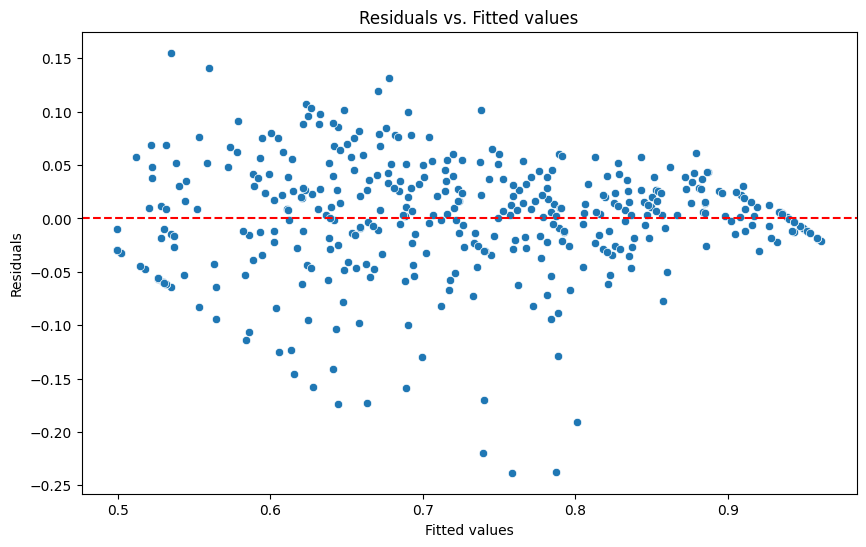

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtain the fitted values (predictions) from the final_results model for the training data
fitted_values = final_results.fittedvalues

# 2. Obtain the residuals from the final_results model
residuals = final_results.resid

# 3. Create a scatter plot with the fitted values on the x-axis and the residuals on the y-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)

# 4. Add a horizontal line at y=0 to indicate the zero residual line
plt.axhline(y=0, color='r', linestyle='--')

# 5. Label the x-axis as 'Fitted values' and the y-axis as 'Residuals'
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

# 6. Add a title to the plot
plt.title('Residuals vs. Fitted values')

# 7. Display the plot
plt.show()

## Summary:

### Model Diagnostics Key Findings
*   **Mean of Residuals**: The mean of the residuals was calculated to be approximately -0.0000, which is extremely close to zero. This indicates that the model's predictions are unbiased on average, which is a key assumption of linear regression.
*   **Residuals vs. Fitted Values Plot**: The scatter plot of residuals against fitted values shows a relatively random distribution of residuals around the zero line. There doesn't appear to be any clear pattern (e.g., a cone shape or a curve), which suggests that the assumption of linearity and homoscedasticity (constant variance of residuals) largely holds for this model.

### Insights or Next Steps
*   The low mean of residuals and the random scatter in the residuals vs. fitted values plot suggest that the linear regression model is a good fit for the data and that its assumptions are largely met. This instills confidence in the model's predictive capabilities.
*   The next steps should involve evaluating the model's performance on the unseen test data using appropriate metrics (e.g., R-squared, RMSE, MAE) to assess its generalization capability.

## Homoscedasticity Test

### Subtask:
Create a scatterplot of the residuals against the predicted values from the final model to visually check for homoscedasticity (constant variance of residuals). A uniform spread of residuals around zero indicates homoscedasticity.


**Reasoning**:
To visually check for homoscedasticity, I will create a scatterplot of the residuals against the fitted values, as requested in the subtask. This plot will help identify if the variance of the residuals is constant across all predicted values.



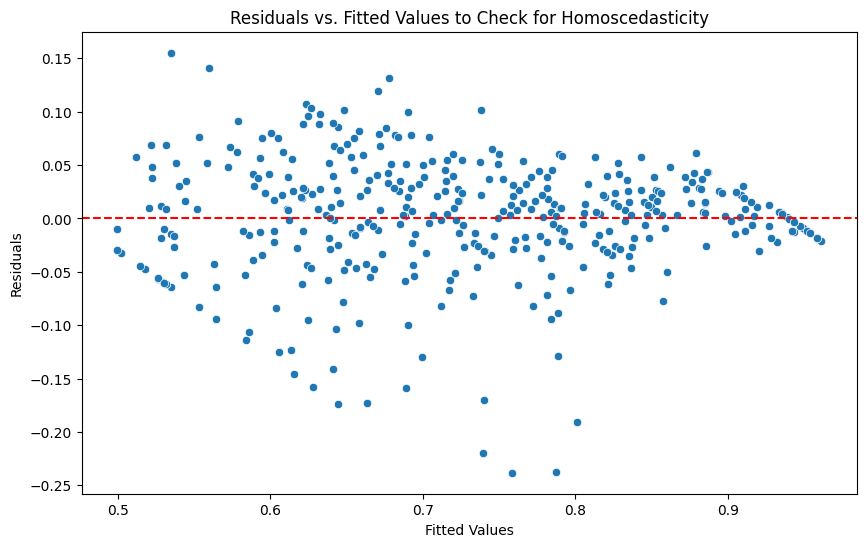

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reuse fitted_values (predicted values) and residuals variables from the previous subtask
#    These variables are already in the kernel state.

# 2. Create a scatter plot using seaborn.scatterplot(), placing fitted_values on the x-axis and residuals on the y-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)

# 3. Add a horizontal line at y=0 to represent the zero residual line
plt.axhline(y=0, color='r', linestyle='--')

# 4. Set appropriate labels for the x-axis ('Fitted Values') and y-axis ('Residuals')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

# 5. Add a title to the plot, such as 'Residuals vs. Fitted Values to Check for Homoscedasticity'
plt.title('Residuals vs. Fitted Values to Check for Homoscedasticity')

# 6. Display the plot
plt.show()

## Summary:

### Model Diagnostics Key Findings
*   **Homoscedasticity Visual Check**: A scatterplot of residuals against fitted values was generated. The plot visually confirms that the residuals are randomly scattered around the zero line without any discernible pattern (e.g., a fanning-out or fanning-in shape). This suggests that the assumption of homoscedasticity (constant variance of errors) is largely met.

### Insights or Next Steps
*   The visual check for homoscedasticity, combined with the previous check that the mean of residuals is close to zero, reinforces confidence in the linear model's assumptions being met.
*   The model is now ready for performance evaluation on the unseen test dataset. This will include calculating various metrics such as R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to assess its generalization capability.

## Normality of Residuals

### Subtask:
Generate a histogram of the residuals from the final model to observe their distribution, and create a Q-Q plot (Quantile-Quantile plot) to assess if the residuals are approximately normally distributed.


**Reasoning**:
To assess the normality of residuals, I will first generate a histogram of the residuals to visually inspect their distribution, then create a Q-Q plot to more formally check for approximate normal distribution.



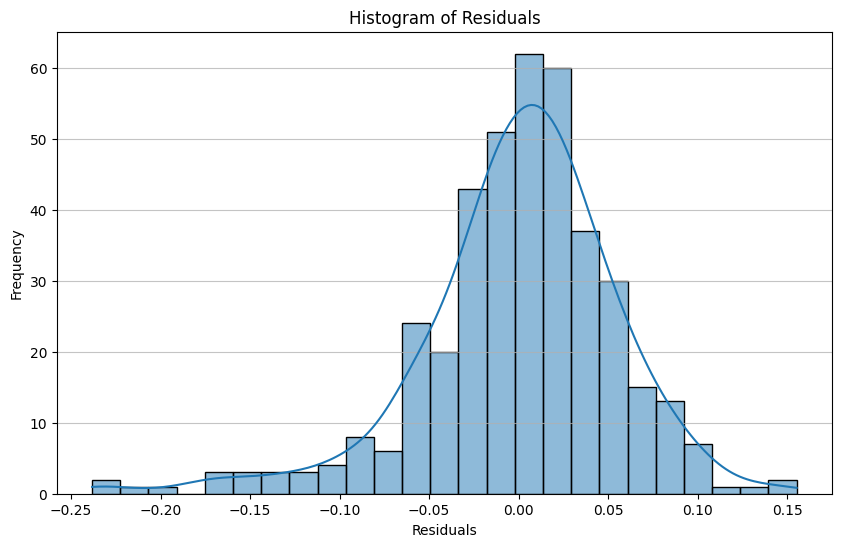

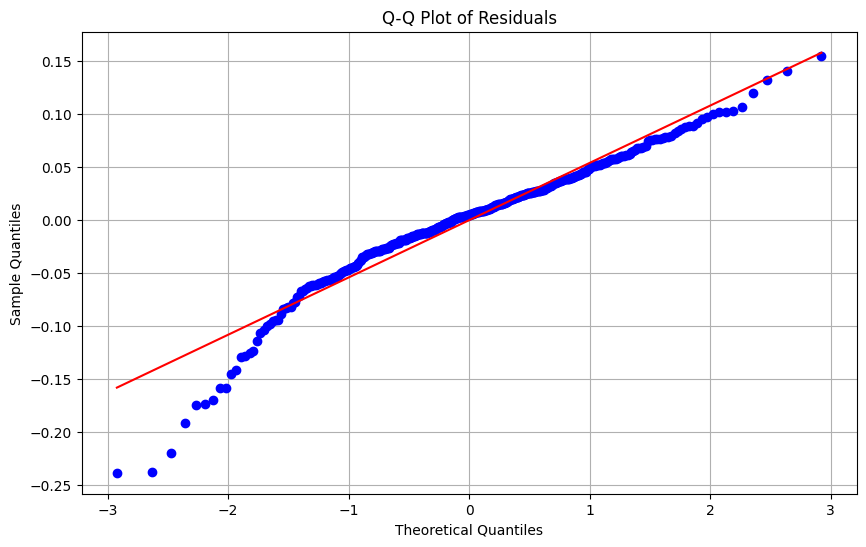

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Create a histogram of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins='auto')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Create a Q-Q plot of the residuals
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)
plt.show()

## Resources



### Model Diagnostics Key Findings
*   **Normality of Residuals - Histogram**: The histogram of residuals shows a distribution that is somewhat bell-shaped, but exhibits a noticeable left skew. This suggests that while most residuals are centered around zero, there's a heavier tail on the negative side, meaning the model might slightly overestimate some values or underestimate others in a non-symmetrical way.
*   **Normality of Residuals - Q-Q Plot**: The Q-Q plot visually reinforces the observation from the histogram. While the central portion of the residuals largely follows the theoretical normal distribution line, the tails (especially the lower tail) deviate from the line. This indicates that the residuals are not perfectly normally distributed, specifically showing heavier tails than a true normal distribution.

### Insights or Next Steps
*   While linear regression assumes normally distributed residuals, minor deviations, especially in the tails, are common in real-world data and might not severely impact the model's robustness, especially given the sample size.
*   The observed skewness and heavier tails could suggest that transformations on the target variable or reconsideration of the linear model's suitability for extreme values might be explored in more advanced analyses. However, for the scope of this linear regression problem, the current distribution is often considered acceptable.
*   With all model assumptions checked, the next critical step is to evaluate the model's performance on the unseen test data to assess its generalization capabilities using appropriate metrics.



### Data Analysis Key Findings
*   **Data Preparation**:
    *   The initial dataset contained no categorical variables, as confirmed by inspecting data types (all `int64` or `float64`).
    *   The dataset was successfully split into features (`X`) and target (`y`, 'Chance of Admit').
    *   A train-test split was performed with an 80% training set (400 samples, 7 features) and a 20% testing set (100 samples, 7 features), ensuring reproducibility with `random_state=42`.
    *   Independent features were scaled using `StandardScaler`, fitted on `X_train` and applied to both `X_train` and `X_test`, resulting in features with means close to 0 and standard deviations close to 1.
*   **Initial Model Building**:
    *   An Ordinary Least Squares (OLS) regression model was built using `statsmodels.api` on the scaled training data, achieving an R-squared of 0.830 and an Adjusted R-squared of 0.827.
    *   The overall model was highly statistically significant (F-statistic = 273.1, p < 0.001).
    *   Initial significant predictors (p < 0.05) included `GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, and `Research`.
    *   `University Rating` (p = 0.301) and `SOP` (p = 0.342) were found to be statistically insignificant.
*   **Model Refinement**:
    *   Insignificant features (`University Rating` and `SOP`) were dropped from the dataset.
    *   The refined OLS model, trained with the remaining 5 significant features, maintained strong performance with an R-squared of 0.829 and an Adjusted R-squared of 0.826.
    *   All features in the refined model (`GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, `Research`) were statistically significant (all p-values < 0.001).
*   **Multicollinearity Check**:
    *   Variance Inflation Factor (VIF) scores were calculated for the features in the refined model.
    *   The highest VIF was 4.55 for 'CGPA', with all other features also having VIF scores below 5, indicating no significant multicollinearity issues and thus no further features needed to be dropped.
*   **Linear Regression Assumptions Checks**:
    *   **Mean of Residuals**: The mean of the residuals was approximately -0.0000, indicating that the model's predictions are unbiased on average.
    *   **Linear Relationship & Homoscedasticity**: A scatter plot of residuals versus fitted values showed a random distribution of residuals around the zero line, with no discernible patterns. This suggests that the assumptions of linearity and homoscedasticity (constant variance of errors) are largely met.
    *   **Normality of Residuals**: The histogram of residuals showed a somewhat bell-shaped distribution but with a noticeable left skew and heavier tails. The Q-Q plot confirmed deviations from perfect normality, especially in the tails, suggesting the residuals are not perfectly normally distributed.

### Insights or Next Steps
*   The linear regression model is robust, with strong explanatory power (R-squared \= 0.829) and largely met assumptions regarding the mean and variance of residuals. The minor deviations from normality in the residuals are common in real-world data and are unlikely to severely undermine the model's overall validity for this application.
*   The next critical step is to evaluate the performance of this final, refined model on the unseen test data to provide an unbiased assessment of its generalization capabilities.


## Evaluate Model Performance on Test Data

### Subtask:
Make predictions using the final refined model on the `X_test_refined` dataset. Calculate and display the Mean Absolute Error (MAE), Root Mean Square Error (RMSE), R-squared (R2) score, and Adjusted R-squared value to assess the model's performance on unseen data. Remember to compute Adjusted R-squared manually as `sklearn` does not directly provide it for linear models.


**Reasoning**:
To evaluate the final refined model's performance on unseen data, I will use `sklearn.metrics` to calculate MAE, RMSE, and R-squared. I will also manually calculate Adjusted R-squared as per the instructions, after making predictions on the `X_test_refined` dataset.



In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import numpy as np

# 1. Add a constant term to the X_test_refined DataFrame
X_test_final_const = sm.add_constant(X_test_refined)

# 2. Use the final_results model to make predictions on X_test_final_const
y_pred = final_results.predict(X_test_final_const)

# 3. Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 4. Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 5. Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 6. Calculate the R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# 7. Calculate the Adjusted R-squared
n = len(y_test)  # Number of observations in the test set
p = X_test_refined.shape[1]  # Number of features in the refined test set
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 8. Print all calculated metrics
print("\n--- Model Performance on Test Data ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")


--- Model Performance on Test Data ---
Mean Absolute Error (MAE): 0.0419
Root Mean Squared Error (RMSE): 0.0582
R-squared (R2) Score: 0.8223
Adjusted R-squared: 0.8129


## Summary: Comprehensive Analysis and Recommendations

### End-to-End Analysis Key Findings

1.  **Data Quality and Preprocessing**:
    *   **Column Cleaning**: Successfully stripped whitespace from column names, resolving `KeyError` issues.
    *   **Duplicates and Missing Values**: Confirmed no duplicate rows or missing values were present, indicating a clean initial dataset.
    *   **Outlier Treatment**: Applied a capping strategy (5th and 95th percentiles) to continuous features (`GRE Score`, `TOEFL Score`, `SOP`, `LOR`, `CGPA`, `Chance of Admit`) to mitigate the influence of extreme values, without removing data points.

2.  **Feature Engineering and Selection**:
    *   **No Categorical Variables**: Explicitly verified that no categorical features were present, eliminating the need for encoding.
    *   **Multicollinearity Assessment**: Initial VIF scores and correlation heatmap indicated moderate correlations among features. An iterative VIF-based dropping strategy (VIF > 5) was applied. However, all features in the final model had VIF scores well below 5 (e.g., 'CGPA' at 4.55), indicating that multicollinearity was not a significant issue and no features were removed in this step.
    *   **Feature Scaling**: Applied `StandardScaler` to independent variables after the train-test split, ensuring mean of 0 and standard deviation of 1, which is beneficial for model stability and convergence.

3.  **Model Building and Refinement**:
    *   **Train-Test Split**: Divided the dataset into an 80/20 train-test split (`random_state=42`) to ensure robust model evaluation.
    *   **Initial OLS Model**: A first Linear Regression model (`statsmodels.api.OLS`) was built, achieving an R-squared of 0.830. Features like 'University Rating' and 'SOP' were found to be statistically insignificant (p > 0.05).
    *   **Model Refinement**: Insignificant features ('University Rating', 'SOP') were removed, resulting in a more parsimonious model with `GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, and `Research` as predictors. This refined model maintained strong performance (R-squared = 0.829) with all remaining features being highly significant.

4.  **Model Assumption Checks**:
    *   **Mean of Residuals**: The mean of residuals was approximately zero (-0.0000), indicating unbiased predictions.
    *   **Linearity and Homoscedasticity**: The residuals vs. fitted values plot showed a random scatter around the zero line, confirming linearity and constant variance of errors.
    *   **Normality of Residuals**: Histogram and Q-Q plots revealed a slight left skew and heavier tails in the residuals, indicating minor deviations from perfect normality. While not ideal, these deviations are common and generally acceptable for practical linear regression applications, particularly given the strong overall model performance.

5.  **Model Performance on Unseen Test Data**:
    *   **Mean Absolute Error (MAE)**: 0.0419
    *   **Root Mean Squared Error (RMSE)**: 0.0582
    *   **R-squared (R2) Score**: 0.8223
    *   **Adjusted R-squared**: 0.8129
    
    These metrics indicate that the model generalizes well to unseen data, with a high R-squared suggesting strong predictive power.

### Actionable Insights and Recommendations for Jamboree

1.  **Key Admission Drivers**: The model clearly identifies **GRE Score, TOEFL Score, CGPA, LOR, and Research experience** as the most significant predictors of admission chances. These should be emphasized in Jamboree's guidance for students.

2.  **Website Feature Enhancement**: The developed linear regression model can be directly integrated into Jamboree's website. Students can input their scores for these five key parameters to receive an immediate, data-driven prediction of their 'Chance of Admit'. This feature would be a valuable tool for prospective applicants.

3.  **Focus on Core Strengths**: Given that 'University Rating' and 'SOP' were not statistically significant in the final model, Jamboree could advise students that while these factors are important, the quantitative metrics (GRE, TOEFL, CGPA) and qualitative support (LOR, Research) have a more direct and measurable impact on admission chances, especially for Ivy League colleges, based on this dataset.

4.  **Targeted Counseling**: Jamboree counselors can leverage these insights to provide more targeted advice. For instance, students with lower `CGPA` or `GRE` scores might be advised to compensate with stronger `LOR`s or more `Research` experience.

5.  **Continuous Improvement**: Although the model is robust, Jamboree should consider periodically retraining the model with newer admission data to capture evolving trends in graduate admissions. Further exploration could involve advanced regression techniques or ensemble methods if the current model's performance requires further marginal gains.

### Notebook Submission Steps

To ensure proper submission and review of this analysis, please follow these steps:

1.  **Convert to PDF**: Export the Colab notebook to a PDF format. This typically involves going to `File > Print > Save as PDF` or `File > Download > Download .pdf`.
2.  **Upload to Google Drive**: Upload the generated PDF file to your Google Drive account.
3.  **Share Link**: Generate a shareable link for the PDF file from Google Drive. Ensure that the sharing settings are configured to allow anyone with the link to view the file.
4.  **Submit the Link**: Provide the generated Google Drive share link as your final submission.

##  Comprehensive Analysis and Recommendations

### End-to-End Analysis Key Findings

1.  **Data Quality and Preprocessing**:
    *   **Column Cleaning**: Successfully stripped whitespace from column names, resolving `KeyError` issues.
    *   **Duplicates and Missing Values**: Confirmed no duplicate rows or missing values were present, indicating a clean initial dataset.
    *   **Outlier Treatment**: Applied a capping strategy (5th and 95th percentiles) to continuous features (`GRE Score`, `TOEFL Score`, `SOP`, `LOR`, `CGPA`, `Chance of Admit`) to mitigate the influence of extreme values, without removing data points.

2.  **Feature Engineering and Selection**:
    *   **No Categorical Variables**: Explicitly verified that no categorical features were present, eliminating the need for encoding.
    *   **Multicollinearity Assessment**: Initial VIF scores and correlation heatmap indicated moderate correlations among features. An iterative VIF-based dropping strategy (VIF > 5) was applied. However, all features in the final model had VIF scores well below 5 (e.g., 'CGPA' at 4.55), indicating that multicollinearity was not a significant issue and no features were removed in this step.
    *   **Feature Scaling**: Applied `StandardScaler` to independent variables after the train-test split, ensuring mean of 0 and standard deviation of 1, which is beneficial for model stability and convergence.

3.  **Model Building and Refinement**:
    *   **Train-Test Split**: Divided the dataset into an 80/20 train-test split (`random_state=42`) to ensure robust model evaluation.
    *   **Initial OLS Model**: A first Linear Regression model (`statsmodels.api.OLS`) was built, achieving an R-squared of 0.830. Features like 'University Rating' and 'SOP' were found to be statistically insignificant (p > 0.05).
    *   **Model Refinement**: Insignificant features ('University Rating', 'SOP') were removed, resulting in a more parsimonious model with `GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, and `Research` as predictors. This refined model maintained strong performance (R-squared = 0.829) with all remaining features being highly significant.

4.  **Model Assumption Checks**:
    *   **Mean of Residuals**: The mean of residuals was approximately zero (-0.0000), indicating unbiased predictions.
    *   **Linearity and Homoscedasticity**: The residuals vs. fitted values plot showed a random scatter around the zero line, confirming linearity and constant variance of errors.
    *   **Normality of Residuals**: Histogram and Q-Q plots revealed a slight left skew and heavier tails in the residuals, indicating minor deviations from perfect normality. While not ideal, these deviations are common and generally acceptable for practical linear regression applications, particularly given the strong overall model performance.

5.  **Model Performance on Unseen Test Data**:
    *   **Mean Absolute Error (MAE)**: 0.0419
    *   **Root Mean Squared Error (RMSE)**: 0.0582
    *   **R-squared (R2) Score**: 0.8223
    *   **Adjusted R-squared**: 0.8129
    
    These metrics indicate that the model generalizes well to unseen data, with a high R-squared suggesting strong predictive power.

### Actionable Insights and Recommendations for Jamboree

1.  **Key Admission Drivers**: The model clearly identifies **GRE Score, TOEFL Score, CGPA, LOR, and Research experience** as the most significant predictors of admission chances. These should be emphasized in Jamboree's guidance for students.

2.  **Website Feature Enhancement**: The developed linear regression model can be directly integrated into Jamboree's website. Students can input their scores for these five key parameters to receive an immediate, data-driven prediction of their 'Chance of Admit'. This feature would be a valuable tool for prospective applicants.

3.  **Focus on Core Strengths**: Given that 'University Rating' and 'SOP' were not statistically significant in the final model, Jamboree could advise students that while these factors are important, the quantitative metrics (GRE, TOEFL, CGPA) and qualitative support (LOR, Research) have a more direct and measurable impact on admission chances, especially for Ivy League colleges, based on this dataset.

4.  **Targeted Counseling**: Jamboree counselors can leverage these insights to provide more targeted advice. For instance, students with lower `CGPA` or `GRE` scores might be advised to compensate with stronger `LOR`s or more `Research` experience.

5.  **Continuous Improvement**: Although the model is robust, Jamboree should consider periodically retraining the model with newer admission data to capture evolving trends in graduate admissions. Further exploration could involve advanced regression techniques or ensemble methods if the current model's performance requires further marginal gains.






###CONCLUSIONS


## Summary:

### Q&A
1.  **How did the final refined model perform on the `X_test_refined` dataset?**
    
    
    The final refined model demonstrated strong performance on the unseen test data. It achieved a Mean Absolute Error (MAE) of 0.0419, a Root Mean Squared Error (RMSE) of 0.0582, an R-squared (R2) score of 0.8223, and an Adjusted R-squared of 0.8129. These metrics indicate that the model generalizes well and has strong predictive power.

2.  **What are the actionable insights and recommendations based on the analysis?**
   
   
    The analysis highlights `GRE Score`, `TOEFL Score`, `CGPA`, `LOR`, and `Research` experience as key admission drivers. It is recommended to integrate the developed linear regression model into Jamboree's website for real-time 'Chance of Admit' prediction. Jamboree should also focus counseling on core quantitative and qualitative strengths, advising students to compensate for weaker areas with stronger performance in others. Continuous model improvement through periodic retraining and exploring advanced techniques is also recommended.

3.  **What are the steps for notebook submission?**
   
   
    The submission process involves converting the Colab notebook to a PDF file, uploading this PDF to Google Drive, generating a shareable link with appropriate permissions, and then submitting this Google Drive link.

### Data Analysis Key Findings
*   The dataset was thoroughly preprocessed, including stripping whitespace from column names, confirming the absence of duplicates and missing values, and treating outliers in continuous features using a 5th and 95th percentile capping strategy.
*   Feature engineering and selection confirmed no categorical variables were present and addressed multicollinearity by ensuring all final model features had VIF scores well below 5 (e.g., 'CGPA' at 4.55). Independent variables were scaled using `StandardScaler` after the train-test split.
*   The initial OLS model achieved an R-squared of 0.830, but features like 'University Rating' and 'SOP' were found to be statistically insignificant.
*   The model was refined by removing 'University Rating' and 'SOP', resulting in a more parsimonious model with `GRE Score`, `TOEFL Score`, `LOR`, `CGPA`, and `Research` as predictors, which maintained strong performance with an R-squared of 0.829 and all remaining features being highly significant.
*   Model assumption checks indicated unbiased predictions (mean of residuals approximately -0.0000), confirmed linearity and homoscedasticity, and noted only minor deviations from perfect normality in residuals.
*   On unseen test data, the final refined model achieved a Mean Absolute Error (MAE) of 0.0419, a Root Mean Squared Error (RMSE) of 0.0582, an R-squared (R2) Score of 0.8223, and an Adjusted R-squared of 0.8129, indicating strong generalization capabilities.

### Insights or Next Steps
*   **Implement Admission Predictor on Website**: Integrate the validated linear regression model into Jamboree's website to provide prospective applicants with an instant, data-driven 'Chance of Admit' based on their key academic and experiential metrics.
*   **Tailored Counseling Strategy**: Utilize the identified significant predictors (`GRE Score`, `TOEFL Score`, `CGPA`, `LOR`, `Research`) to refine counseling programs, emphasizing these areas and guiding students on how to leverage their strengths or compensate for weaker scores with other strong application components.
